## 1. Import các thư viện cần thiết

**Mục tiêu:**  
Import các thư viện Pandas, NumPy và Matplotlib để xử lý dữ liệu, tính toán và trực quan hóa sau này.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Xây dựng mô hình Decision Tree Regressor từ đầu

Các thành phần chính:

- **Node**: lưu thông tin của từng nút trong cây.
- **DecisionTreeRegressor**: quản lý toàn bộ quá trình xây dựng và dự đoán bằng cây quyết định.
- Sử dụng phương pháp đệ quy để chia dữ liệu thành các nút con.
- Điều kiện dừng gồm:
  - Đạt độ sâu tối đa (`max_depth`).
  - Số lượng mẫu nhỏ hơn `min_samples_split`.
  - Phương sai của biến mục tiêu bằng 0.
- Giá trị dự đoán tại nút lá được tính bằng trung bình của các mẫu trong nút đó.

In [ ]:
# CÀI ĐẶT CÂY QUYẾT ĐỊNH 

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

    def is_leaf_node(self): # Kiểm tra xem nút có phải là nút lá không
        return self.value is not None # Nếu giá trị không phải None thì đây là nút lá

class DecisionTreeRegressor:
    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        max_features=None,
        random_state=None
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.root = None

        if random_state is not None:
            np.random.seed(random_state)

    def fit(self, X, y): 
        # 1. HÀM FIT: Nhận dữ liệu và bắt đầu mọc cây
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        y_array = y.values if isinstance(y, pd.Series) else y
        self.root = self._grow_tree(X_array, y_array)

    def _grow_tree(self, X, y, depth=0):
            n_samples, n_feats = X.shape

            # Điều kiện biên để dừng phân tách cây
            if (
                (self.max_depth is not None and depth >= self.max_depth) # Dừng nếu đạt độ sâu tối đa
                or n_samples < self.min_samples_split # Dừng nếu số mẫu nhỏ hơn ngưỡng
                or np.var(y) == 0.0 # Dừng nếu phương sai bằng 0
            ):

               leaf_value = np.mean(y) # Giá trị lá là trung bình của y
               return Node(value=leaf_value)
            
            feat_idxs = np.arange(n_feats)
            if self.max_features is not None:
                feat_idxs = np.random.choice(
                    feat_idxs,
                    min(self.max_features, n_feats),
                    replace=False
                )

            # Tìm kiếm điểm chia tốt nhất (Best Split) trên toàn bộ không gian đặc trưng
            best_feat, best_thresh = self._best_split(X, y, feat_idxs)


            if best_feat is None:
                return Node(value=np.mean(y))

            # Tạo nhánh con đệ quy
            left_idxs = np.argwhere(X[:, best_feat] <= best_thresh).flatten()
            right_idxs = np.argwhere(X[:, best_feat] > best_thresh).flatten()
            
            if len(left_idxs) == 0 or len(right_idxs) == 0:
                return Node(value=np.mean(y))

            left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
            right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
            return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -np.inf
        best_feat = None
        best_thresh = None
        
        current_variance = np.var(y) * len(y)
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            sorted_idx = np.argsort(X_column)
            sorted_X = X_column[sorted_idx]
            sorted_y = y[sorted_idx]
            
            for i in range(1, len(sorted_y)):
                if sorted_X[i] == sorted_X[i-1]:
                    continue
                    
                thresh = (sorted_X[i-1] + sorted_X[i]) / 2.0
                
                left_idxs = sorted_idx[:i]
                right_idxs = sorted_idx[i:]
                
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                
                var_l = np.var(sorted_y[:i])
                var_r = np.var(sorted_y[i:])
                n_l, n_r = len(left_idxs), len(right_idxs)
                
                variance_reduction = current_variance - (n_l * var_l + n_r * var_r)
                
                if variance_reduction > best_gain:
                    best_gain = variance_reduction
                    best_feat = feat_idx
                    best_thresh = thresh
                    
        if best_gain <= 0:
            return None, None
        return best_feat, best_thresh

    def predict(self, X):
        # 4. HÀM PREDICT: Dự đoán hàng loạt
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_array])

    def _traverse_tree(self, x, node):
        # 5. HÀM TRAVERSE_TREE: Duyệt từng dòng dữ liệu từ gốc đến lá
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Huấn luyện, Thử nghiệm và so sánh max_depth

**Mục tiêu:**  
Đánh giá ảnh hưởng của tham số `max_depth` đến chất lượng mô hình trên tập validation.  
Giúp nhận diện hiện tượng overfitting khi tăng độ sâu của cây.

Sau khi huấn luyện, mô hình được đánh giá bằng các chỉ số:

- **MAE (Mean Absolute Error)**: sai số tuyệt đối trung bình.
- **MSE (Mean Squared Error)**: sai số bình phương trung bình.
- **RMSE (Root Mean Squared Error)**: căn bậc hai của MSE.
- **R^2 (R-squared)**: hệ số xác định.


In [ ]:
X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").iloc[:,0]
y_val = pd.read_csv("y_val.csv").iloc[:,0]
y_test = pd.read_csv("y_test.csv").iloc[:,0]

In [ ]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())
print(X_val.columns.tolist())

['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_log', 'sqft_living_log', 'month_sold', 'age', 'is_renovated', 'years_since_renovated', 'has_basement', 'distance_to_center', 'zipcode_freq']
['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_log', 'sqft_living_log', 'month_sold', 'age', 'is_renovated', 'years_since_renovated', 'has_basement', 'distance_to_center', 'zipcode_freq']
['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_log', 'sqft_living_log', 'month_sold', 'age', 'is_renovated', 'years_since_renovated', 'has_basement', 'distance_to_center', 'zipcode_freq']


In [ ]:
# xóa cột price
X_train = X_train.drop(columns=['price_log'])
X_test = X_test.drop(columns=['price_log'])
X_val = X_val.drop(columns=['price_log'])

In [ ]:
print("=" * 70)
print("SO SÁNH MAX_DEPTH")
print("=" * 70)

max_depth_list = [3, 5, 7, 10, 15, 20, None]

results_depth = []

for depth in max_depth_list:

    model = DecisionTreeRegressor(
        max_depth=depth,
        max_features=None,
        min_samples_split=2,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Validation metrics
    mae = np.mean(np.abs(y_val - y_val_pred))
    mse = np.mean((y_val - y_val_pred) ** 2)
    rmse = np.sqrt(mse)

    # R² Train
    ss_res_train = np.sum((y_train - y_train_pred) ** 2)
    ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
    r2_train = 1 - (ss_res_train / ss_tot_train)

    # R² Validation
    ss_res_val = np.sum((y_val - y_val_pred) ** 2)
    ss_tot_val = np.sum((y_val - np.mean(y_val)) ** 2)
    r2_val = 1 - (ss_res_val / ss_tot_val)

    results_depth.append([
        str(depth),
        mae,
        rmse,
        r2_train,
        r2_val
    ])

results_depth = pd.DataFrame(
    results_depth,
    columns=[
        "Max Depth",
        "MAE (Val)",
        "RMSE (Val)",
        "R2 Train",
        "R2 Val"
    ]
)

print(results_depth)

SO SÁNH MAX_DEPTH
  Max Depth      MAE (Val)     RMSE (Val)  R2 Train    R2 Val
0         3  132211.509627  218400.696467  0.625116  0.636892
1         5  108726.585675  186139.451288  0.781445  0.736242
2         7   95584.427883  166955.506071  0.849506  0.787808
3        10   89604.759927  165452.552340  0.922522  0.791611
4        15   93911.409235  175306.009165  0.984187  0.766051
5        20   98515.339855  178679.271268  0.997965  0.756961
6      None   99683.635831  179355.119632  1.000000  0.755119


### Nhận xét

- Khi tăng `max_depth` từ **3** lên **10**, mô hình học được nhiều quy luật hơn nên:
  - **MAE** giảm từ **132,211.51** xuống **89,604.76**.
  - **RMSE** giảm từ **218,400.70** xuống **165,452.55**.
  - **R² Validation** tăng từ **0.6369** lên **0.7916**.

  Điều này cho thấy việc tăng độ sâu của cây giúp mô hình khai thác tốt hơn mối quan hệ giữa các đặc trưng và giá nhà, từ đó cải thiện đáng kể độ chính xác trên tập kiểm tra.

- **Max Depth = 10** là cấu hình cho kết quả tốt nhất:
  - **MAE** và **RMSE** đạt giá trị nhỏ nhất.
  - **R² Validation** đạt giá trị cao nhất (**0.7916**).
  - **R² Train = 0.9225** và **R² Validation = 0.7916** không chênh lệch quá lớn, cho thấy mô hình có khả năng tổng quát hóa tốt và chưa xuất hiện hiện tượng overfitting nghiêm trọng.

- Khi tiếp tục tăng `max_depth` lên **15**, **20** hoặc **None**:
  - **R² Train** tăng rất cao, đạt gần **1.0**.
  - Tuy nhiên **R² Validation** lại giảm từ **0.7916** xuống còn khoảng **0.755**.
  - Đồng thời **MAE** và **RMSE** đều tăng trở lại.

  Điều này cho thấy mô hình bắt đầu **overfitting**, tức là học quá chi tiết dữ liệu huấn luyện nên khả năng dự đoán trên dữ liệu chưa từng thấy bị suy giảm.

### Kết luận

- **Max Depth = 10** là giá trị tối ưu sau khi loại bỏ cột `price`, vì đạt **R² Validation cao nhất (0.7916)** và đồng thời có **MAE** cùng **RMSE** thấp nhất.
- Việc loại bỏ cột `price` không làm mô hình mất khả năng dự đoán, chứng tỏ các đặc trưng còn lại vẫn chứa đủ thông tin để dự báo giá nhà.
- Không nên sử dụng `max_depth` quá lớn (15, 20 hoặc `None`) vì mặc dù độ chính xác trên tập huấn luyện tăng lên, hiệu suất trên tập kiểm tra lại giảm do hiện tượng **overfitting**.

## 4. Huấn luyện mô hình chính thức (max_depth = 10)

**Mục tiêu:**  
Huấn luyện mô hình với cấu hình được chọn và đánh giá chi tiết trên các tập Train, Validation và Test.

In [ ]:

model = DecisionTreeRegressor(max_depth = 10,
                               max_features = None,
                               min_samples_split = 2)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

mae = np.mean(np.abs(y_val - y_val_pred))
mse = np.mean((y_val - y_val_pred) ** 2)
rmse = np.sqrt(mse)

ss_res_train = np.sum((y_train - y_train_pred) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - (ss_res_train / ss_tot_train)

ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_test = 1 - (ss_res / ss_tot)

ss_res = np.sum((y_val - y_val_pred) ** 2)
ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
r2_val = 1 - (ss_res / ss_tot)


print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"1. MAE (Mean Absolute Error)     : {mae:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"4. R² Train                      : {r2_train:.4f}")
print(f"5. R² Test                       : {r2_test:.4f}")
print(f"6. R² Val                        : {r2_val:.4f}")


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. MAE (Mean Absolute Error)     : 89604.7599
2. MSE (Mean Squared Error)      : 27374547075.7540
3. RMSE (Root Mean Squared Error): 165452.5523
4. R² Train                      : 0.9225
5. R² Test                       : 0.7716
6. R² Val                        : 0.7916


### Nhận xét kết quả huấn luyện chính thức (`max_depth = 10`)

Sau khi lựa chọn **`max_depth = 10`** là tham số tối ưu, mô hình Decision Tree được huấn luyện chính thức và đạt các kết quả sau:

- **MAE = 89,604.76**, cho thấy sai số tuyệt đối trung bình giữa giá dự đoán và giá thực tế khoảng **89.6 nghìn USD**. Đây là mức sai số tương đối thấp so với khoảng giá trị của bộ dữ liệu, chứng tỏ mô hình dự đoán khá chính xác.

- **MSE = 27,374,547,075.75** phản ánh tổng bình phương sai số của mô hình. Do MSE bình phương đơn vị sai số nên giá trị thường lớn và chủ yếu được sử dụng để đánh giá mức độ ảnh hưởng của các dự đoán sai lệch lớn.

- **RMSE = 165,452.55** cho biết sai số dự đoán trung bình của mô hình vào khoảng **165.5 nghìn USD**. Vì RMSE có cùng đơn vị với biến mục tiêu nên chỉ số này dễ diễn giải và cho thấy mô hình vẫn tồn tại một số dự đoán có sai số lớn nhưng nhìn chung vẫn đạt hiệu quả tốt.

- **R² Train = 0.9225** nghĩa là mô hình giải thích được khoảng **92.25%** sự biến thiên của giá nhà trên tập huấn luyện. Điều này cho thấy mô hình học được phần lớn mối quan hệ giữa các đặc trưng và biến mục tiêu.

- **R² Test = 0.7716** và **R² Validation = 0.7916** đều ở mức khá cao, chứng tỏ mô hình vẫn duy trì được khả năng dự đoán tốt trên dữ liệu chưa từng được huấn luyện.

- Chênh lệch giữa **R² Train (0.9225)** và **R² Test (0.7716)** khoảng **15%**, trong khi **R² Validation (0.7916)** gần với **R² Test**, cho thấy mô hình có xuất hiện **overfitting nhẹ** nhưng vẫn nằm trong mức chấp nhận được và có khả năng tổng quát hóa tốt.

### Kết luận

- Mô hình **Decision Tree với `max_depth = 10`** là lựa chọn phù hợp nhất sau quá trình thử nghiệm.
- Mô hình đạt **độ chính xác cao**, giải thích được khoảng **77–79%** sự biến thiên của giá nhà trên dữ liệu mới.
- Các chỉ số **MAE**, **RMSE** và **R²** đều cho thấy mô hình có hiệu suất tốt và cân bằng giữa khả năng học trên tập huấn luyện và khả năng dự đoán trên tập kiểm tra, phù hợp để sử dụng cho bài toán dự đoán giá nhà.

## 5. Lưu kết quả dự đoán

In [ ]:
test_df_out = pd.read_csv("X_test.csv")

test_df_out["Actual Price"] = y_test
test_df_out["Predicted Price"] = y_test_pred

output_file = "DecisionTree_Predictions.csv"

test_df_out.to_csv(output_file, index=False)

print(f"\nSaved {len(test_df_out)} rows to {output_file}")


Saved 3242 rows to DecisionTree_Predictions.csv


## 6. Trực quan hóa: Actual vs Predicted

**Mục tiêu:**  
Đánh giá trực quan mức độ khớp giữa giá trị thực tế và giá trị mô hình dự đoán. Điểm càng nằm gần đường chéo (đường đỏ đứt) càng cho thấy mô hình dự đoán tốt.

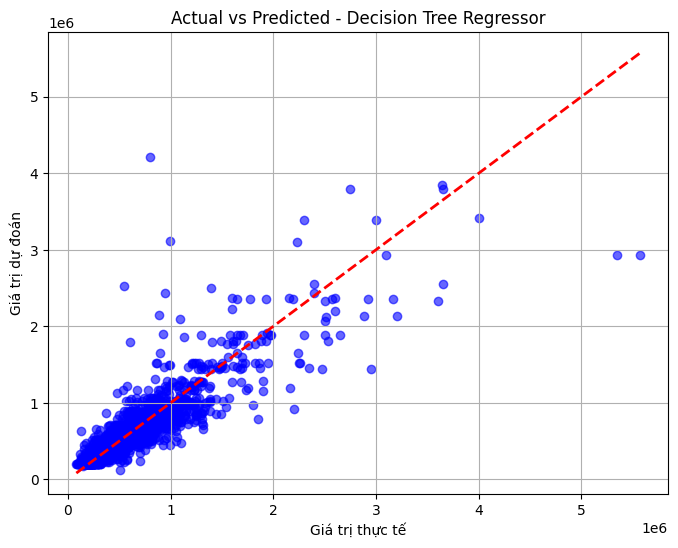

In [ ]:


# Giả sử dùng model với max_depth=10
y_test_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Actual vs Predicted - Decision Tree Regressor')
plt.grid(True)
plt.show()

### Nhận xét biểu đồ Actual vs Predicted

- Phần lớn các điểm dữ liệu nằm gần đường chéo **y = x**, cho thấy giá trị dự đoán khá sát với giá trị thực tế.
- Ở các căn nhà có mức giá thấp và trung bình, mô hình dự đoán tương đối chính xác với sai số nhỏ.
- Đối với các căn nhà có giá trị rất cao, các điểm dữ liệu phân tán xa đường chéo hơn, cho thấy mô hình dự đoán chưa tốt và sai số tăng lên.
- Nhìn chung, mô hình Decision Tree với **`max_depth = 10`** có khả năng dự đoán tốt, tuy nhiên hiệu quả giảm đối với các trường hợp có giá trị ngoại lệ hoặc quá lớn.

## 7. Residual Plot (Biểu đồ Sai số)

**Mục tiêu:**  
Xem mô hình sai lệch bao nhiêu so với giá trị thực tế.

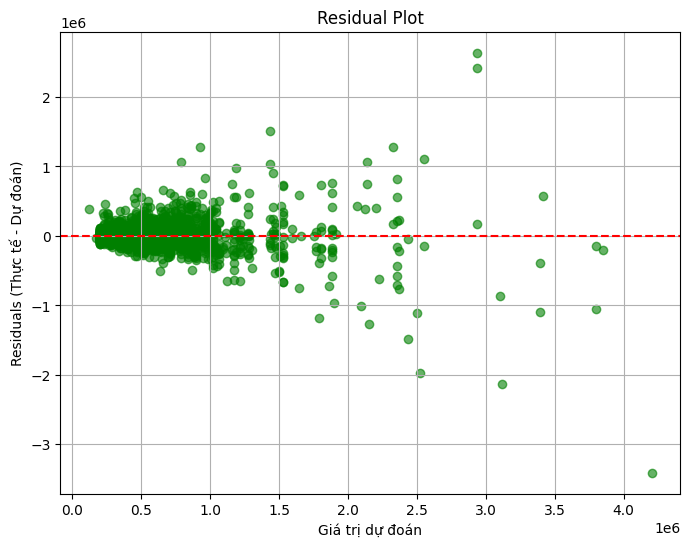

In [ ]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Residuals (Thực tế - Dự đoán)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

### Nhận xét Residual Plot

- Phần lớn **residuals** phân bố quanh đường **0**, cho thấy mô hình không có xu hướng dự đoán cao hoặc thấp một cách hệ thống.
- Với các giá trị dự đoán nhỏ và trung bình, sai số tập trung khá sát đường 0, chứng tỏ mô hình dự đoán tương đối chính xác.
- Khi giá trị dự đoán tăng, độ phân tán của residuals cũng tăng và xuất hiện một số điểm ngoại lệ, cho thấy mô hình dự đoán kém chính xác hơn đối với các căn nhà có giá trị cao.
- Nhìn chung, mô hình hoạt động tốt nhưng vẫn bị ảnh hưởng bởi một số giá trị ngoại lệ và các mẫu có giá trị lớn.